<a href="https://colab.research.google.com/github/GITANO1031/6650/blob/main/assignments/assn2/assn2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Intermediate Machine Learning: Assignment 2

**Deadline**

Assignment 2 is due Thursday, October  9 by 11:59 pm. Late work will not be accepted as per the course policies (see the syllabus on Canvas).

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. Acknowledge any use of an AI system such as ChatGPT or Copilot.

You should start early so that you have time to get help if you're stuck. The drop-in office hours schedule can be found on Canvas. You can also post questions or start discussions on Ed Discussion. The assignment may look long at first glance, but the problems are broken up into steps that should help you to make steady progress.

**Submission**

Submit your assignment as a .pdf on Gradescope. To convert your notebook to a .pdf while preserving the cell structure without truncating the output, you can convert to .html using [this notebook](https://colab.research.google.com/github/YData123/sds365-fa25/blob/main/assignments/Convert_ipynb_to_HTML_in_Colab.ipynb). Note: When submitting on Gradescope, please select the correct pages of your pdf that correspond to each problem. This will allow graders to more easily find your complete solution to each problem.

**Topics**

 * Convolutional neural nets
 * Gaussian processes
 * Double descent

Please note that while the problems may look long, we give you substantial starter code to make the work manageable. The course staff members are available to help during office hours!

## Problem 1: Dilation elation (35 points)

### Overview

A dilated convolution (also known as atrous convolution) inserts gaps between kernel entries, so that a $k \times k$ filter “jumps” by a dilation rate $𝑑$. A dilation rate of $d=1$ is the regular convolution. CNN dilation can be adjusted using parameter $d$ as shown in the figure below.  



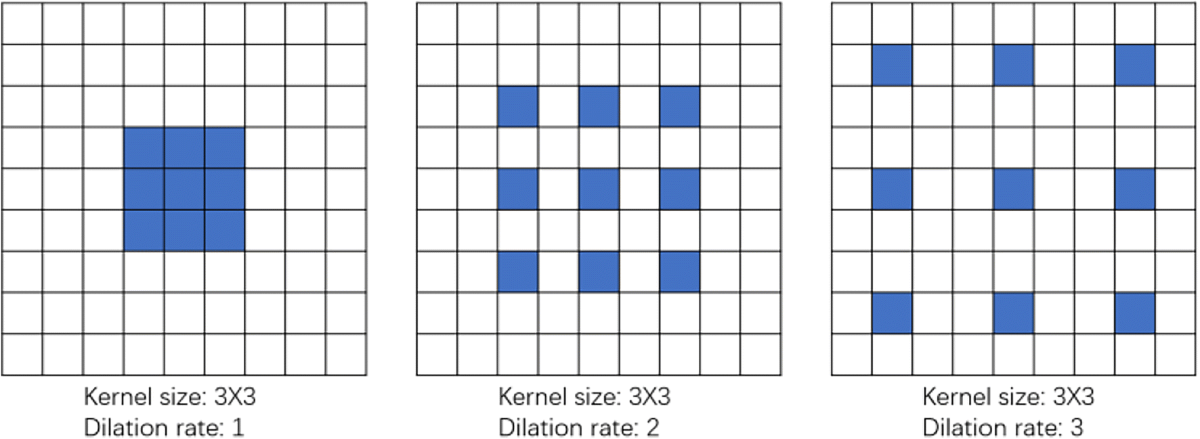




Dilated convolution captures a wider area of the input, allowing for potentially better context modeling without increased computational cost. It expands the effective "receptive field" (the area of the filter) without the need for larger kernels or more model parameters; dilated convolution can also reduce blurring. One of the most successful uses of  dilated convolution was in the first AlphaFold paper, one of the earliest CNN-based attempts to predict the structure of proteins. For a glimpse of the full architecture and its details you may wish to take a look at https://www.nature.com/articles/s41586-019-1923-7

In this problem, we use dilated convolution to analyze MRI images to detect the presence of certain types of brain tumors. Cues about tumor type can include texture information (enhanced rim, necrotic core) and global characteristics (edema extent, mass effect, midline shift). Dilation expands the effective receptive field while keeping high-resolution features available for downstream neural network layers that make the multi-class decision. This approach is also helps address the problem of "anisotropy" where some characteristics are directionally dependent, by trying to incorporate a larger sub image in the kernel.

In the first part of this problem, we implement a regular CNN. Then, your job will be to implement a dilated CNN, and to choose the dilation parameters so that the model is as accurate as you can make it.  Finally, we use Monte Carlo dropout as a way to estimate the uncertainty in the predictions.

### Dilated convolution in one and two dimensions

**Symbols (what each letter means):**
- $x$: the **input** (a 1D signal for the first formula; a 2D image for the second).
- $y$: the **output feature map** after convolution (same shape type as $x$).
- $w \in \mathbb{R}^{k}$: a 1D **kernel/filter** of length $k$.
- $W \in \mathbb{R}^{k\times k}$: a 2D **kernel/filter** of size $k \times k$.
- $k$: **kernel size** (e.g., $k=3$ for a $3\times3$ kernel).
- $d$: **dilation rate** (how far apart the kernel taps are; $d=1$ is a standard convolution).
- $i,j$: spatial **indices** of the output $y$ (row/column).
- $m,u,v$: **indices inside the kernel** (1D: $m$, 2D: $u$ for rows, $v$ for cols).
- $u_c=\lfloor k/2\rfloor$, $v_c=\lfloor k/2\rfloor$: the **kernel center** offsets (so the kernel is centered).
- We assume **stride $=1$** and appropriate padding so indices are valid.


---
---


**1D dilated convolution** of a signal $x$ with kernel $w \in \mathbb{R}^{k}$ and dilation $d \in \mathbb{N}$:
$$
y[i] \;=\; \sum_{m=0}^{k-1} w[m]\; x\!\bigl(i + d\,m\bigr).
$$

**2D dilated convolution** of an image $x$ with kernel $W \in \mathbb{R}^{k\times k}$ and dilation $d$ (stride $1$).  
Let $u_c=\lfloor k/2\rfloor$ and $v_c=\lfloor k/2\rfloor$ denote the kernel center:
$$
y[i,j] \;=\; \sum_{u=0}^{k-1}\sum_{v=0}^{k-1}
W[u,v]\; x\!\bigl(i + d\,(u-u_c),\; j + d\,(v-v_c)\bigr).
$$

**Effective receptive field** of a $k\times k$ kernel with dilation $d$:
$$
k_{\text{eff}} \;=\; k + (k-1)\,(d-1).
$$

For example, for $k=3$ and $d=3$, we get $k_{\text{eff}}=7$.  
(When $d=1$, this reduces to the standard convolution.)

### Loading the MRI data

The data used in this problem is cropped from this Kaggle repository https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset.

We only use the data corresponding to glioma tumors and non-tumor images. You can access the data in a zip file at [https://github.com/YData123/sds365-fa25/tree/main/assignments/assn2/](https://github.com/YData123/sds365-fa25/tree/main/assignments/assn2/).
You will need to upload the data to your Google Drive.

The cell below gives Colab access to your Google Drive.


In [1]:
# Please do not edit this cell.
# Imports
import os, random, time, math, keras, json
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import layers as L, models as M

# (Colab) Mount Google Drive
from google.colab import drive
if not os.path.ismount("/content/drive"):
  drive.mount("/content/drive")

Mounted at /content/drive


Now that we mounted Google Drive let's try visualizing images in the training data for the tumor and non-tumor classes.

In [2]:
# Do not edit this block.
# Point to the MRI/ folder that contains Training/ and Testing/
ROOT = "/content/drive/MyDrive/MRI"

TRAIN_DIR = os.path.join(ROOT, "Training")
TEST_DIR  = os.path.join(ROOT, "Testing")
CLASS_NAMES = ["glioma", "notumor"]  # expected two folders inside both training/ and testing/

# Validation of directory structure
def assert_dir(p):
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Expected directory not found: {p}")

assert_dir(ROOT)
assert_dir(TRAIN_DIR)
assert_dir(TEST_DIR)

# Load image as grayscale for consistent viewing
def load_img_gray(path):
    img = Image.open(path).convert("L")  # force grayscale
    return img

# List image files in a folder
def count_images(folder):
    exts = ("*.jpg", "*.jpeg")
    files = []
    for e in exts:
        files.extend(glob(os.path.join(folder, e)))
    return sorted(files)

The data we have requires pre-processing in order to be fed to any neural networks. The inconsistencies in the size as you see in the above output becomes problematic during feeding the data to the network. In this block, we strive to solve that issue.

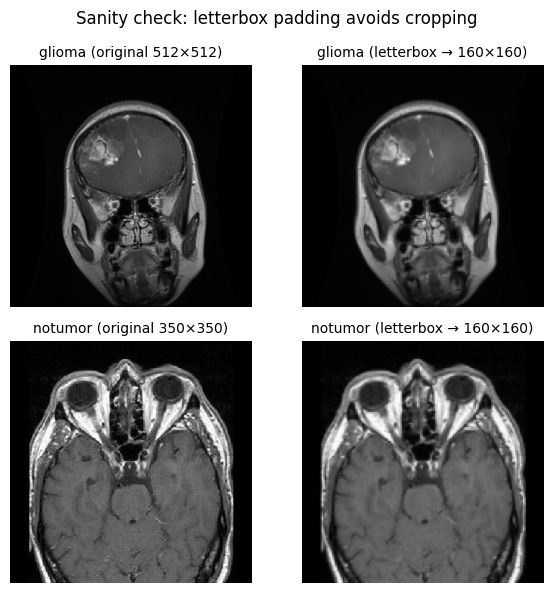

In [3]:
# Helper functions: letterbox pad to square (no cropping) + resize to 160x160

IMG_SIZE = 160  # target size used throughout the assignment

def letterbox_to_square(img: Image.Image, fill=0) -> Image.Image:
    """
    Pads the image to a square using 'fill' (black), centered, without distortion.
    Keeps original content intact (no cropping).
    """
    if img.mode not in ("L", "RGB"):
        img = img.convert("L")
    w, h = img.size
    s = max(w, h)
    canvas = Image.new(img.mode, (s, s), color=fill)
    canvas.paste(img, ((s - w)//2, (s - h)//2))
    return canvas

def preprocess_image(img: Image.Image, size: int = IMG_SIZE) -> Image.Image:
    """Letterbox pad -> resize to (size, size)."""
    sq = letterbox_to_square(img, fill=0)
    return sq.resize((size, size), resample=Image.BILINEAR)

# Visualize ORIGINAL vs PREPROCESSED (letterboxed) for first training image of each class
fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(6, 3*len(CLASS_NAMES)))
if len(CLASS_NAMES) == 1:
    axes = np.array([axes])  # ensure 2D array indexing

for i, c in enumerate(CLASS_NAMES):
    class_dir = os.path.join(TRAIN_DIR, c)
    files = count_images(class_dir)
    ax_orig, ax_proc = axes[i, 0], axes[i, 1]
    if not files:
        ax_orig.axis("off"); ax_proc.axis("off")
        ax_proc.set_title(f"No images found for {c}")
        continue

    p = files[0]
    img = load_img_gray(p)            # original grayscale
    proc = preprocess_image(img)      # padded + resized 160x160

    ax_orig.imshow(img, cmap="gray");  ax_orig.axis("off")
    ax_orig.set_title(f"{c} (original {img.size[0]}×{img.size[1]})", fontsize=10)

    ax_proc.imshow(proc, cmap="gray"); ax_proc.axis("off")
    ax_proc.set_title(f"{c} (letterbox → {IMG_SIZE}×{IMG_SIZE})", fontsize=10)

plt.suptitle("Sanity check: letterbox padding avoids cropping", fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
# Gather file paths & labels; split TRAIN into train/validation (TEST untouched)

def list_images_with_labels(root_dir, classes):
    paths, labels = [], []
    for ci, cname in enumerate(classes):
        cdir = os.path.join(root_dir, cname)
        for p in count_images(cdir):
            paths.append(p); labels.append(ci)
    return np.array(paths), np.array(labels)

# load TRAIN and TEST file lists
train_paths, train_labels = list_images_with_labels(TRAIN_DIR, CLASS_NAMES)
test_paths,  test_labels  = list_images_with_labels(TEST_DIR,  CLASS_NAMES)

# stratified split of TRAIN -> (train, val)
VAL_FRACTION = 0.20
tr_paths, val_paths, tr_labels, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=VAL_FRACTION,
    random_state=42,
    stratify=train_labels
)

print(f"Counts -> train: {len(tr_paths)}, val: {len(val_paths)}, test: {len(test_paths)}")

Counts -> train: 2332, val: 584, test: 705


In [5]:
# TensorFlow input pipeline with the SAME preprocessing:
# grayscale -> letterbox to square (no crop) -> resize to IMG_SIZE -> per-image z-score

def tf_letterbox_resize(img, target=IMG_SIZE):
    shape = tf.shape(img)
    h, w = shape[0], shape[1]
    s = tf.maximum(h, w)
    pad_top  = (s - h) // 2
    pad_bottom = s - h - pad_top
    pad_left = (s - w) // 2
    pad_right = s - w - pad_left
    img_sq = tf.pad(img, [[pad_top, pad_bottom],[pad_left, pad_right],[0,0]], mode="CONSTANT", constant_values=0.0)
    img_rs = tf.image.resize(img_sq, (target, target), method="bilinear")
    return img_rs

def tf_per_image_zscore(img):
    mean = tf.reduce_mean(img)
    std  = tf.math.reduce_std(img)
    return (img - mean) / tf.maximum(std, 1e-6)

def load_and_preprocess(path, label, augment=False):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=1, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf_letterbox_resize(img, target=IMG_SIZE)

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.10)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)

    img = tf_per_image_zscore(img)
    label = tf.cast(label, tf.float32)
    label = tf.expand_dims(label, axis=-1)   # (1,)
    return img, label

def make_dataset(paths, labels, batch_size=32, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: load_and_preprocess(p, y, augment=augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

BATCH_SIZE = 16
ds_train = make_dataset(tr_paths,  tr_labels,  batch_size=BATCH_SIZE, shuffle=True,  augment=True)
ds_val   = make_dataset(val_paths, val_labels, batch_size=BATCH_SIZE, shuffle=False, augment=False)
ds_test  = make_dataset(test_paths, test_labels, batch_size=BATCH_SIZE, shuffle=False, augment=False)

for xb, yb in ds_train.take(1):
    print("Train batch:", xb.shape, yb.shape)

Train batch: (16, 160, 160, 1) (16, 1)


/tmp/ipython-input-1886849759.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c = int(yb[i])


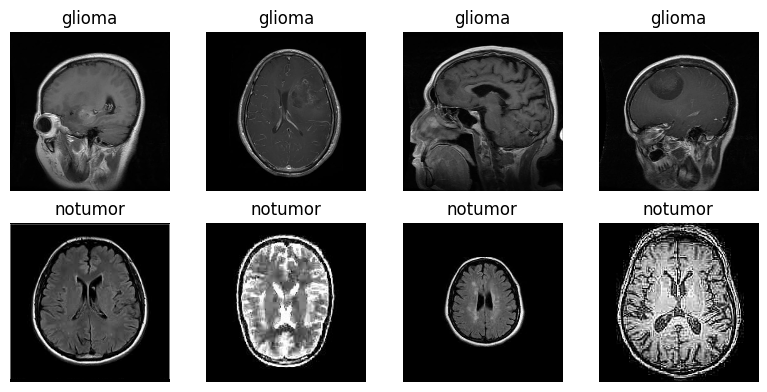

In [6]:
# Quick visual sanity check: Show 4 preprocessed samples per class from the TRAIN pipeline
class_names = CLASS_NAMES

# collect a small batch
xb, yb = next(iter(ds_train))
xb = xb.numpy(); yb = yb.numpy()

fig, axes = plt.subplots(2, 4, figsize=(8,4))
axes = axes.reshape(-1)
shown = {i:0 for i in range(len(class_names))}
for i in range(len(xb)):
    c = int(yb[i])
    if shown[c] >= 4:
        continue
    axes[c*4 + shown[c]].imshow(xb[i,...,0], cmap="gray")
    axes[c*4 + shown[c]].axis("off")
    axes[c*4 + shown[c]].set_title(class_names[c])
    shown[c]+=1
    if all(v==4 for v in shown.values()):
        break
plt.tight_layout(); plt.show()

In [7]:
"""
You'll learn two new layers in this assignment. MCSpatialDropout2D is a smarter type of dropout for image processing
networks. Instead of randomly turning off individual pixels, it turns off entire channels (feature detectors) all at
once. This works better for images because it prevents the network from getting too dependent on specific feature
detectors working together, which helps it generalize better to new data. BatchNormalization helps keep your network's
internal signals stable during training. It takes the outputs from each layer and normalizes them (resembling standardizing
data), then applies two learnable parameters to scale and shift the results as needed. This makes training more stable and
often lets you use higher learning rates, leading to faster and more reliable training.
"""
# Keras model factory: Build a baseline CNN
# Force-dropout layers that stay active at inference for MC sampling (BatchNorm stays frozen)
@keras.saving.register_keras_serializable(package="mc")
class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs, training=None):
        # Force sampling masks even at inference for MC passes
        return super().call(inputs, training=True)

@keras.saving.register_keras_serializable(package="mc")
class MCSpatialDropout2D(tf.keras.layers.SpatialDropout2D):
    def call(self, inputs, training=None):
        # Force sampling masks even at inference for MC passes
        return super().call(inputs, training=True)

def build_cnn(
    dilated=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 1),
    num_classes=1,                # 1 sigmoid unit (binary)
    drop_rate=0.20,
    use_mc_dropout=True,          # if True, use MC* layers; else standard Dropout
    use_spatial=True              # SpatialDropout2D is usually better for convs
):
    """
    Tiny CNN; toggle dilation in block-2 convs. Adds dropout so MC sampling works.
    - dilated=False: Conv3x3 (rate=1)
    - dilated=True : dilation rates (2,3,5) in the 2nd conv of each block
    - Dropout: after each block; optionally before Dense head
    """
    rates = (1,1,1)

    Drop = (MCSpatialDropout2D if (use_mc_dropout and use_spatial) else
            L.SpatialDropout2D if use_spatial else
            MCDropout if use_mc_dropout else
            L.Dropout)

    x_in = L.Input(shape=input_shape)
    x = x_in

    # Block A
    x = L.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(32, 3, padding="same", activation="relu", dilation_rate=rates[0])(x)
    x = L.BatchNormalization()(x)
    x = L.MaxPool2D(pool_size=2)(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    # Block B
    x = L.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(64, 3, padding="same", activation="relu", dilation_rate=rates[1])(x)
    x = L.BatchNormalization()(x)
    x = L.MaxPool2D(pool_size=2)(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    # Block C
    x = L.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(128, 3, padding="same", activation="relu", dilation_rate=rates[2])(x)
    x = L.BatchNormalization()(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = L.Dropout(drop_rate)(x)  # a small dense-level dropout is fine (standard)

    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)  # binary head
    model = tf.keras.Model(x_in, out)
    return model

# Rebuild models (students then train as in Step 14)
model_base = build_cnn(dilated=False)
model_base.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d            │ (None, 80, 80, 32)     │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_1          │ (None, 40, 40, 64)     │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_2          │ (None, 40, 40, 128)    │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             

 Total params: 288,353 (1.10 MB)

 Trainable params: 287,457 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

### Problem 1.1: Explain the CNN

The cell above shows layer of the CNN, with the output tensor shape and the number of trainable parameters. For each layer, explain in a couple of sentences (1) what the purpose of the layer is (2) why the output shape and number of parameters are as shown.

- input_layer:
  - to define the input tensor
  - the output size is (160, 160, 1) which is the same as the input size
  - there're no learnable parameters since it's an input layer
- conv2d:
  - to extract basic features and produce feature maps
  - the output size is (160, 160, 32): the kernel size is (3, 3) but the layer pads the output to the same size as the input, which is (160, 160); the last dimension is 32 since there're 32 kernels
  - param #: $trainable=(3\times3\times1+1)\times32=320$, there're $32$ kernels, each with the shape of $3\times3\times1$ and $1$ intercept
- batch_normalization:
  - to normalize and to stabilize training
  - the output size is (160, 160, 32) which is the same as the input size since it only does the normalization
  - param #:
    - $trainable=32\times2=64$, every chanel has two learnable parameters to scale and shift the results s needed
    - $non-trainanle=32\times2=64$, every chanel has a mean and a variance when normalized
- conv2d_1:
  - to use dialted convolution to expand the effective receptive field, capturing features at a wider range
  - the output size is (160, 160, 32) since the layer pads the output to the same size as the input
  - param #: $trainable=(3\times3\times32+1)\times32=9248$, here're $32$ kernels, each with the shape of $3\times3\times32$ and $1$ intercept
- batch_normalization_1:
  - also to normalize and to stabilize training
  - the output size is (160, 160, 32) which is the same as the input size since it only does the normalization
  - param #:
    - $trainable=32\times2=64$, every chanel has two learnable parameters to scale and shift the results s needed
    - $non-trainanle=32\times2=64$, every chanel has a mean and a variance when normalized
- max_pooling2d:
  - to downgrade the dimension
  - the output size is (80, 80, 32), since the pool size is (2, 2) and the input size is (160, 160, 32): $160/2=80$
  - param #: 0, max pooling does not need params
- mc_spatial_dropout2d:
   - to dropout several data in the training process in case of overfitting by turning off entire channels, to prevent the network from getting too dependent on specific feature detectors working together
   - the output size is (80, 80, 32) which is the same as the input size since it only does the dropout
   - param #: 0, dropout does not need params
- conv2d_2:
  - to learn mid-level features and produce feature maps
  - the output size is (80, 80, 64): the layer pads the output to the same size as the input which is (80, 80); the last dimension is 64 since there're 64 kernels
  - param #: $trainable=(3\times3\times32+1)\times64=18496$, there're $64$ kernels, each with the shape of $3\times3\times32$ and $1$ intercept
- batch_normalization_2:
  - also to normalize and to stabilize training
  - the output size is (80, 80, 64) which is the same as the input size since it only does the normalization
  - param #:
    - $trainable=64\times2=128$, every chanel has two learnable parameters to scale and shift the results s needed
    - $non-trainanle=64\times2=128$, every chanel has a mean and a variance when normalized
- conv2d_3:
  - to use dialted convolution to expand the effective receptive field, capturing features at a wider range
  - the output size is (80, 80, 64) since the layer pads the output to the same size as the input which is (80, 80); the last dimension is 64 since there're 64 kernels
  - param #: $trainable=(3\times3\times64+1)\times32=36928$, here're $64$ kernels, each with the shape of $3\times3\times64$ and $1$ intercept
- batch_normalization_3:
  - also to normalize and to stabilize training
  - the output size is (80, 80, 64) which is the same as the input size since it only does the normalization
  - param #:
    - $trainable=64\times2=128$, every chanel has two learnable parameters to scale and shift the results s needed
    - $non-trainanle=64\times2=128$, every chanel has a mean and a variance when normalized
- max_pooling2d_1:
  - to downgrade the dimension
  - the output size is (40, 40, 64), since the pool size is (2, 2) and the input size is (80, 80, 64): $80/2=40$
  - param #: 0, max pooling does not need params
- mc_spatial_dropout2d_1:
   - to dropout several data in the training process in case of overfitting by turning off entire channels, to prevent the network from getting too dependent on specific feature detectors working together
   - the output size is (40, 40, 64) which is the same as the input size since it only does the dropout
   - param #: 0, dropout does not need params
- conv2d_4:
  - to learn high-level features and produce feature maps
  - the output size is (40, 40, 128): the layer pads the output to the same size as the input which is (40, 40); the last dimension is 128 since there're 128 kernels
  - param #: $trainable=(3\times3\times64+1)\times128=73856$, there're $128$ kernels, each with the shape of $3\times3\times64$ and $1$ intercept
- batch_normalization_4:
  - also to normalize and to stabilize training
  - the output size is (40, 40, 128) which is the same as the input size since it only does the normalization
  - param #:
    - $trainable=128\times2=256$, every chanel has two learnable parameters to scale and shift the results s needed
    - $non-trainanle=128\times2=256$, every chanel has a mean and a variance when normalized
- conv2d_5:
  - to use dialted convolution to expand the effective receptive field, capturing features at a wider range
  - the output size is (40, 40, 128) since the layer pads the output to the same size as the input which is (40, 40); the last dimension is 128 since there're 128 kernels
  - param #: $trainable=(3\times3\times128+1)\times128=147584$, here're $128$ kernels, each with the shape of $3\times3\times128$ and $1$ intercept
- batch_normalization_5:
  - also to normalize and to stabilize training
  - the output size is (40, 40, 128) which is the same as the input size since it only does the normalization
  - param #:
    - $trainable=128\times2=256$, every chanel has two learnable parameters to scale and shift the results s needed
    - $non-trainanle=128\times2=256$, every chanel has a mean and a variance when normalized
- mc_spatial_dropout2d_2:
   - to dropout several data in the training process in case of overfitting by turning off entire channels, to prevent the network from getting too dependent on specific feature detectors working together
   - the output size is (40, 40, 128) which is the same as the input size since it only does the dropout
   - param #: 0, dropout does not need params
- global_average_pooling2d:
  - to average each feature map to a single value which could compact representations and reduce the number of parameters
  - the output size is (128), since it does the average on each channel, and the number of channels is 128
  - param #: 0, average pooling does not need params
- dropout:
  - to prevent overfitting before the final classifier
  - the output size is (128) which is the same as the input size since it only does the dropout
  - param #: 0, dropout does not need params
- dense:
  - to do the binary classification
  - the output size is (1), since it finally gives a result of the classification
  - param #: $trainable=128+1=129$, each input has a param and there's 1 intercept


The following cell now trains the baseline CNN, and evaluates it on test data.

In [8]:
# Train the baseline model (with validation) + evaluate on TEST + plots

EPOCHS  = 10
OUTDIR  = "/content/drive/MyDrive"
os.makedirs(OUTDIR, exist_ok=True)

def compile_model(m):
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-5),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5)])
    return m

def train_model(model, name, train_ds, val_ds, epochs=EPOCHS):
    ckpt = os.path.join(OUTDIR, f"{name}.keras")  # best checkpoint
    cbs = [ModelCheckpoint(ckpt, monitor="val_accuracy", save_best_only=True, verbose=1)]
    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cbs, verbose=1)
    train_seconds = time.time() - t0
    print(f"[TIMER] {name}: training wall-clock = {train_seconds:.2f} sec "
          f"({train_seconds/max(1,len(hist.history['loss'])):.2f} sec/epoch) (monitoring val_accuracy)")
    # OPTIONAL: save the final weights separately (do NOT overwrite ckpt)
    final_path = os.path.join(OUTDIR, f"{name}_final.keras")
    model.save(final_path)
    return ckpt, hist, train_seconds

def evaluate_and_report(model, ds, class_names):
    y_true, y_pred = [], []
    out_last_dim = model.output_shape[-1]  # 1 for sigmoid, 2 for softmax
    for xb, yb in ds:
        probs = model.predict(xb, verbose=0)
        probs = np.array(probs).reshape((probs.shape[0], -1))
        preds = (probs[:,0] >= 0.5).astype(int) if out_last_dim == 1 else np.argmax(probs, axis=1)
        yt = yb.numpy().reshape(-1).astype(int)
        y_true.append(yt); y_pred.append(preds)
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    return y_true, y_pred

def measure_eval_time(model, ds, n_samples):
    t0 = time.time()
    loss, acc = model.evaluate(ds, verbose=0)
    eval_seconds = time.time() - t0
    print(f"[TIMER] evaluate: {eval_seconds:.2f} sec")
    t1 = time.time()
    _ = model.predict(ds, verbose=0)
    pred_seconds = time.time() - t1
    ips = n_samples / pred_seconds if pred_seconds > 0 else float("inf")
    print(f"[TIMER] predict : {pred_seconds:.2f} sec  (~{ips:.1f} images/sec)")
    return loss, acc, eval_seconds, pred_seconds, ips

In [9]:


# --- compile
model_base = compile_model(model_base)

# --- train with validation (no test leakage)
ckpt_base, hist_base, train_time_base = train_model(model_base, "baseline_cnn", ds_train, ds_val, epochs=EPOCHS)

# --- reload best and evaluate on TEST (timed)
model_base = tf.keras.models.load_model(ckpt_base)

print("\n[TEST] Baseline:")
y_true_base, y_pred_base = evaluate_and_report(model_base, ds_test, CLASS_NAMES)
loss_b, acc_b, eval_t_b, pred_t_b, ips_b = measure_eval_time(model_base, ds_test, n_samples=len(test_paths))

print(f"\n[TEST] Baseline -> loss: {loss_b:.4f} | acc: {acc_b:.4f}")



Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5755 - loss: 0.6724
Epoch 1: val_accuracy improved from -inf to 0.45377, saving model to /content/drive/MyDrive/baseline_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 499s 3s/step - accuracy: 0.5759 - loss: 0.6721 - val_accuracy: 0.4538 - val_loss: 1.2723
Epoch 2/10
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7045 - loss: 0.5619
Epoch 2: val_accuracy improved from 0.45377 to 0.45548, saving model to /content/drive/MyDrive/baseline_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7048 - loss: 0.5617 - val_accuracy: 0.4555 - val_loss: 1.2781
Epoch 3/10
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7631 - loss: 0.5184
Epoch 3: val_accuracy improved from 0.45548 to 0.46918, saving model to /content/drive/MyDrive/baseline_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7633 - loss: 0.5181 - val_accuracy: 0.4692 - val_loss: 1.0192
Epoch 4/10
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 48m

### Problem 1.2: Improve on the baseline with a dilated CNN

Your job is now to use the above code, appropriately modified as needed, to build and train a dilated CNN that has better accuracy than the baseline.

Note that the keras Conv2D method can handle dilation. You may experiment with any architecture (combination of layers) and dilation parameters that you wish.

To keep the notebook clear, only show your best model, not intermediate, experimental models. Explain your choice of model, and why your best dilation CNN model does or does not improve on the baseline. Note that you should use a runtime environment that uses a GPU for faster processing speed.

In [10]:
def build_dilated_cnn(
    dilated=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 1),
    num_classes=1,                # 1 sigmoid unit (binary)
    drop_rate=0.20,
    use_mc_dropout=True,          # if True, use MC* layers; else standard Dropout
    use_spatial=True              # SpatialDropout2D is usually better for convs
):
    """
    Tiny CNN; toggle dilation in block-2 convs. Adds dropout so MC sampling works.
    - dilated=False: Conv3x3 (rate=1)
    - dilated=True : dilation rates (2,3,5) in the 2nd conv of each block
    - Dropout: after each block; optionally before Dense head
    """
    rates = (2,3,5) if dilated else (1,1,1)

    Drop = (MCSpatialDropout2D if (use_mc_dropout and use_spatial) else
            L.SpatialDropout2D if use_spatial else
            MCDropout if use_mc_dropout else
            L.Dropout)

    x_in = L.Input(shape=input_shape)
    x = x_in

    # Block A
    x = L.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(32, 3, padding="same", activation="relu", dilation_rate=rates[0])(x)
    x = L.BatchNormalization()(x)
    x = L.MaxPool2D(pool_size=2)(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    # Block B
    x = L.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(64, 3, padding="same", activation="relu", dilation_rate=rates[1])(x)
    x = L.BatchNormalization()(x)
    x = L.MaxPool2D(pool_size=2)(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    # Block C
    x = L.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(128, 3, padding="same", activation="relu", dilation_rate=rates[2])(x)
    x = L.BatchNormalization()(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = L.Dropout(drop_rate)(x)  # a small dense-level dropout is fine (standard)

    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)  # binary head
    model = tf.keras.Model(x_in, out)
    return model

model_dilated = build_dilated_cnn(dilated=True)
model_dilated.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_3          │ (None, 80, 80, 32)     │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_4          │ (None, 40, 40, 64)     │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_5          │ (None, 40, 40, 128)    │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             

 Total params: 288,353 (1.10 MB)

 Trainable params: 287,457 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
model_dilated = compile_model(model_dilated)

# --- train with validation (no test leakage)
ckpt_dilated, hist_dilated, train_time_dilated = train_model(model_dilated, "dilated_cnn", ds_train, ds_val, epochs=EPOCHS)

# --- reload best and evaluate on TEST (timed)
model_dilated = tf.keras.models.load_model(ckpt_dilated)

print("\n[TEST] dilated:")
y_true_dilated, y_pred_dilated = evaluate_and_report(model_dilated, ds_test, CLASS_NAMES)
loss_b, acc_b, eval_t_b, pred_t_b, ips_b = measure_eval_time(model_dilated, ds_test, n_samples=len(test_paths))

print(f"\n[TEST] dilated -> loss: {loss_b:.4f} | acc: {acc_b:.4f}")

Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6080 - loss: 0.6510
Epoch 1: val_accuracy improved from -inf to 0.45377, saving model to /content/drive/MyDrive/dilated_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 34s 151ms/step - accuracy: 0.6083 - loss: 0.6507 - val_accuracy: 0.4538 - val_loss: 0.9062
Epoch 2/10
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7461 - loss: 0.5138
Epoch 2: val_accuracy did not improve from 0.45377
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.7463 - loss: 0.5136 - val_accuracy: 0.4538 - val_loss: 1.1917
Epoch 3/10
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8142 - loss: 0.4357
Epoch 3: val_accuracy improved from 0.45377 to 0.58048, saving model to /content/drive/MyDrive/dilated_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.8143 - loss: 0.4355 - val_accuracy: 0.5805 - val_loss: 0.7643
Epoch 4/10
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8549 - loss: 0.3691
Epoch 4: val_accura

For my dilated CNN, I only modified the provided baseline CNN model by replacing the second normal convolution layer in each block with a dilated convolution layer with dilation rates (2, 3, 5) for each one.

The result on the test dataset for the baseline model is loss: 0.2821 | acc: 0.8993, while the result for the dilated model is loss: loss: 0.1917 | acc: 0.9248.

The dilated CNN is actually improving the baseline because the dilated convolutions could expand the effective receptive field of each convolutional layer without increasing the number of parameters, which allows it to capture global patterns in the images better.

### Problem 1.3 Monte Carlo dropout to assess model uncertainty

Your CNN should use Monte Carlo (MC) dropout to compute the risk at test time. For a fixed MRI image scan $x$, you obtain $T$ stochastic predictions $\{\hat y_t\}_{t=1}^T$.

<br>

**(a) Mean and variance from MC passes.**
Give mathematical expressions for the MC estimate of the predictive mean $\mu_T$ and its variance $s_T^2$ from $\{\hat y_t\}$.

<br>

$\mu_T=\frac{1}{T}\sum_{t=1}^T \hat y_t$

$s_T^2 = \frac{1}{T-1}\sum_{t=1}^T (\hat y_t - \mu_T)^2=\frac{1}{T-1}\sum_{t=1}^T (\hat y_t - \frac{1}{T}\sum_{t=1}^T \hat y_t)^2$

<br>

**(b) Accuracy guarantee.**
Using Chebyshev's inequality, derive a lower bound on $T$ ensuring
$\Pr\!\big(|\mu_T-\mu_{\text{true}}|\ge \varepsilon\big)\le \delta$.
Express the minimal $T$ in terms of $\operatorname{Var}(\hat y_t)$ (or a plug-in estimate).
Clearly state any assumptions you need to make, such as Gaussianity.

<br>

Assume that the MC samples are i.i.d. with its variance near the pilot estimate, we have $\operatorname{Var}(\mu_T) = \operatorname{Var}\left(\frac{1}{T}\sum_{t=1}^T \hat y_t \right) = \frac{1}{T^2}\operatorname{Var}\left(\sum_{t=1}^T \hat y_t \right) = \frac{1}{T^2}\sum_{t=1}^T \operatorname{Var}(\hat y_t) = \frac{\operatorname{Var}(\hat y_t)}{T}$

Using Chebyshev's inequality, we know that $\Pr\!\big(|\mu_T - \mu_{\text{true}}| \ge \varepsilon\big) \le \frac{\operatorname{Var}(\mu_T)}{\varepsilon^2}
= \frac{\operatorname{Var}(\hat y_t)}{T \varepsilon^2}$

To force the $RHS \le \delta$, we need
$\frac{\operatorname{Var}(\hat y_t)}{T \,\varepsilon^2} \le \delta
\implies T \;\ge\; \frac{\operatorname{Var}(\hat y_t)}{\delta\,\varepsilon^2}$

<br>

**(c) Numerical budget.**
With target $\varepsilon=0.05$, confidence $1-\delta=0.95$ ($\delta=0.05$), a pilot of $T_0=50$ passes giving standard deviation $s_{T_0}^2=0.08$, compute the required $T$ from part (b). Describe what this means--what guarantee does this give about the accuracy of the prediction?

<br>

$T\ge\frac{\operatorname{Var}(\hat y_t)}{\delta\,\varepsilon^2}=\frac{0.08}{0.05 \times 0.05^2}=640$

It means that with 640 MC dropouts, Chebyshev's inequality guarantees that the estimated predictive mean $\mu_T$ will deviate from the true predictive mean $\mu_{\text{true}}$ by at most 0.05 with probability at least $95\%$

### Problem 1.4 Monte Carlo (MC) Dropout on test images

You will implement MC Dropout to quantify predictive uncertainty at test time. By keeping Dropout active during inference and sampling the model multiple times on the same inputs, you will approximate the posterior predictive distribution and summarize it with a mean prediction and a dispersion measure (standard deviation). Use MC Dropout to approximate the posterior predictive and quantify epistemic uncertainty at test time. Keep dropout on during inference, sample the model multiple times on the same inputs, and summarize the resulting distribution. Set the number of stochastic forward passes to a reasonable value based on the outputs you obtain. Remember by default model.predict does not keep dropout active at inference.

In this part you will:

1.   Build A sampler function that deterministically picks the first 5 images per class from the test set folder for each label (10 images in total)
2.   A stochastic inference predictive route that runs the model with dropout active and returns one probability per image in each round. Your CNN models is preferably defined as a function so that you can feed the baseline and dilated CNNs to compare the values here.
3. Calculate the mean and standard deviation of the stochastic forward passes in step 2 to generate a table or grid that depicts idices, y_true, y_hat,p_mean, p_std. The two latter values should be obtained with your stochastic forward passes with dropout on.
4. See if there is a mispredicted label based on your y_hat, then discuss the correlation between standard deviation of the stochastic runs and the final y_hat.

In [12]:
def sampler():
    sampled_paths = []
    sampled_labels = []
    for ci, cname in enumerate(CLASS_NAMES):
        cdir = os.path.join(TEST_DIR, cname)
        for p in count_images(cdir)[:5]:
            sampled_paths.append(p)
            sampled_labels.append(ci)
    return np.array(sampled_paths), np.array(sampled_labels)

def stochastic_inference(model, ds, n_passes):
    x_batch, _ = next(iter(ds))

    all_probs = []
    for _ in range(n_passes):
        probs = model.predict(x_batch)
        # probs = model(x_batch, training=True).numpy()
        all_probs.append(probs.reshape(-1))

    all_probs = np.array(all_probs)
    return all_probs

import pandas as pd

def summarize_predictions(true_labels, all_probs):
    mean_probs = np.mean(all_probs, axis=0)
    std_probs = np.std(all_probs, axis=0)
    preds = (mean_probs >= 0.5).astype(int)

    # Create a summary table
    summary = pd.DataFrame({
        'index': np.arange(len(mean_probs)),
        'y_true': true_labels,
        'y_hat': preds,
        'p_mean': mean_probs,
        'p_std': std_probs
    })

    return summary

def find_mispredictions(summary):
    mispredictions = summary[summary['y_true'] != summary['y_hat']]
    return mispredictions

In [14]:
sampled_paths, sampled_labels = sampler()
ds_test_first_5  = make_dataset(sampled_paths, sampled_labels, batch_size=BATCH_SIZE, shuffle=False, augment=False)

n_passes = 100
all_probs_dilated = stochastic_inference(model_dilated, ds_test_first_5, n_passes)
summary_dilated = summarize_predictions(sampled_labels, all_probs_dilated)
mispredictions_dilated = find_mispredictions(summary_dilated)

print("Dilated Model Summary:\n", summary_dilated)
print("Dilated Mispredictions in Model:\n", mispredictions_dilated)

all_probs_baseline = stochastic_inference(model_base, ds_test_first_5, n_passes)
summary_baseline = summarize_predictions(sampled_labels, all_probs_baseline)
mispredictions_baseline = find_mispredictions(summary_baseline)

print("Baseline Model Summary:\n", summary_baseline)
print("Baseline Mispredictions in Model:\n", mispredictions_baseline)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━

##### 2

Both models achieved the same prediction accuracy (9/10 correct). However, the dilated model exhibited slightly lower predictive standard deviations on correctly classified samples, which means that the dilated model has reduced epistemic uncertainty and more stable predictions.

Besides, both models have a slightly increase in p_std for the mispredicted sample (index 5), indicating that when models confuse they have a higher uncertainty.

And the p_std of the mispredicted sample is higher in the dilated model than the baseline model, which might suggest that the dilated model is more sensitive to the uncertainty and knows better that confusions might be caused there.

##### 4

For most correctly predicted samples, the standard deviation is relatively low, indicating that the model's predictions across the MC dropout passes are relatively stable.

For the mispredicted sample (index 5), p_std is slightly higher than some correctly predicted samples, indicating that the model is uncertain about this prediction.

During the dropout process, p_std can be used as an indicator of uncertainty. High p_std suggests that the model has low confidence in the prediction y_hat, which should be reviewed with further analysis, while low p_std suggests that the prediction of y_hat is more trustworthy.

## Problem 2: All that glitters (20 points)

In this problem you will use Gaussian process regression to model the trends in gold medal performances of selected events in the summer Olympics. The objectives of this problem are for you to:

* Gain experience with Gaussian processes, to better understand how they work
* Explore how posterior inference depends on the properties of the prior mean and kernel
* Use Bayesian inference to identify unusual events
* Practice making your Python code modular and reusable

For this problem, the only starter code we provide is to read in the data and extract
one event. You may write any GP code that you choose to, but please do not use any
package for Gaussian processes; your code should be "np-complete" (using only
basic `numpy` methods). You are encouraged to start from the [GP demo code](https://ydata123.org/fa24/interml/calendar.html) used in class.


When we ran the GP demo code from class on the marathon data, it generated the following plot:
<img src="https://github.com/YData123/sds365-fa22/raw/main/assignments/assn2/marathon.jpg" width="600">

Note several properties of this plot:
* It shows the Bayesian confidence of the regression, as a shaded area. This is a 95% confidence band because it has width given by $\pm 2 \sqrt{V}$, where $V$ is the estimated variance. The variance increases at the right side, for future years.

* The gold medal time for the 1904 marathon is outside of this confidence band. In fact, the 1904 marathon was an [unusual event](https://www.smithsonianmag.com/history/the-1904-olympic-marathon-may-have-been-the-strangest-ever-14910747/), and this is apparent from the model.

* The plot shows the posterior mean, and also shows one random sample from the posterior distribution.

Your task in this problem is generate such a plot for six different Olympic events by writing a function

`def gp_olympic_event(year, result, kernel, mean, noise, event_name):
    ...`
    
 where the input variables are the following:

* `year`: a numpy array of years (integers)
* `result`: a numpy array of numerical results, for the gold medal performances in that event
* `kernel`: a kernel function
* `mean`: a mean function
* `noise`: a single float for the variance of the noise, $\sigma^2$
* `event_name`: a string used to label the y-axis, for example "marathon min/mile (men's event)"

Your function should compute the Gaussian process regression, and then display the resulting plot, analogous to the plot above for the men's marathon event.

You will then process **six** of the events, three men's events and three women's events, and call your function to generate the corresponding six plots.

For each event, you should create a markdown cell that describes the resulting model. Comment on such things as:

* How you chose the kernel, mean, and noise.
* Why the plot does or doesn't look satisfactory to you
* If there are any events such as the 1904 marathon that are notable.
* What happens to the posterior mean (for example during WWII) if there are gaps in the data

Use your best judgement to describe your findings; post questions to EdD if things are unclear. And have fun!



------------------

In the remainder of this problem description, we recall how we processed the marathon data, as an example. The following cell reads in the data and displays the collection of events that are included in the dataset.

In [ ]:
import numpy as np
import pandas as pd

dat = pd.read_csv('https://raw.githubusercontent.com/YData123/sds365-fa25/main/demos/gaussian_processes/olympic_results.csv')
events = set(np.array(dat['Event']))
print(events)

{'100M Men', '800M Men', 'Marathon Men', '20Km Race Walk Men', '4X100M Relay Women', 'Shot Put Women', 'Long Jump Men', '400M Hurdles Women', '4X100M Relay Men', 'Pole Vault Women', 'Heptathlon Women', '20Km Race Walk Women', '10000M Men', 'Decathlon Men', '400M Hurdles Men', '400M Women', '3000M Steeplechase Men', '5000M Men', '5000M Women', 'Hammer Throw Women', 'Discus Throw Men', 'Discus Throw Women', 'Javelin Throw Women', 'Triple Jump Women', 'Hammer Throw Men', '1500M Women', '100M Women', '3000M Steeplechase Women', '4X400M Relay Men', '4X400M Relay Women', 'Marathon Women', 'Shot Put Men', '100M Hurdles Women', '10000M Women', 'Javelin Throw Men', '50Km Race Walk Men', 'Triple Jump Men', 'High Jump Men', '1500M Men', '200M Women', 'Long Jump Women', '200M Men', 'Pole Vault Men', 'High Jump Women', '800M Women', '110M Hurdles Men', '400M Men'}


We then process the time to compute the minutes per mile (without checking that the race was actually 26.2 miles!)

In [ ]:
marathon = dat[dat['Event'] == 'Marathon Men']
marathon = marathon[marathon['Medal']=='G']
marathon = marathon.sort_values('Year')
time = np.array(marathon['Result'])
mpm = []
for tm in time:
    t = np.array(tm.split(':'), dtype=float)
    minutes_per_mile = (t[0]*60*60 + t[1]*60 + t[2])/(60*26.2)
    mpm.append(minutes_per_mile)

marathon['Minutes per Mile'] = np.round(mpm,2)
marathon = marathon.drop(columns=['Gender', 'Event'], axis=1)
marathon.reset_index(drop=True, inplace=True)
year = np.array(marathon['Year'])
result = np.array(marathon['Minutes per Mile'])
marathon

,Location,Year,Medal,Name,Nationality,Result,Minutes per Mile
0,Athens,1896,G,Spyridon LOUIS,GRE,2:58:50,6.83
1,Paris,1900,G,Michel THÃATO,FRA,2:59:45.0,6.86
2,St Louis,1904,G,Thomas HICKS,USA,3:28:53.0,7.97
3,London,1908,G,John HAYES,USA,2:55:18.4,6.69
4,Stockholm,1912,G,Kennedy Kane MCARTHUR,RSA,2:36:54.8,5.99
5,Antwerp,1920,G,Hannes KOLEHMAINEN,FIN,2:32:35.8,5.82
6,Paris,1924,G,Albin STENROOS,FIN,2:41:22.6,6.16
7,Amsterdam,1928,G,BoughÃ¨ra EL OUAFI,FRA,2:32:57,5.84
8,Los Angeles,1932,G,Juan Carlos ZABALA,ARG,2:31:36,5.79
9,Berlin,1936,G,Kitei SON,JPN,2:29:19.2,5.70


Enter your code and markdown following this cell.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import cholesky
from scipy.spatial.distance import cdist
from IPython.display import clear_output
from time import sleep

def gaussian_sample(mu, Sigma):
    A = cholesky(Sigma)
    Z = np.random.normal(loc=0, scale=1, size=len(mu))
    return np.dot(A, Z) + mu

def mu_fun(x, mu=0):
    return mu * np.ones(len(x))

def rbf_K_fun(x, z, h=1):
    K = np.zeros(len(x)*len(z)).reshape(len(x), len(z))
    for j in np.arange(K.shape[1]):
        K[:,j] = (1/h)*np.exp(-(x-z[j])**2/(2*h**2))
    return K

In [ ]:
def gp_olympic_event(year, result, kernel, mean, noise, event_name):
    Xtrain = year
    ytrain = np.array(result)
    xs = np.linspace(min(year)-1, max(year)+10, 500)

    K = kernel(Xtrain, Xtrain)
    Ks = kernel(Xtrain, xs)
    Kss = kernel(xs, xs) + noise * np.eye(len(xs))
    Ki = np.linalg.inv(K + noise * np.eye(len(Xtrain)))

    mu_train = mean(Xtrain)
    mu_test = mean(xs)

    postMu = mu_test + Ks.T @ Ki @ (ytrain - mu_train)
    postCov = Kss - Ks.T @ Ki @ Ks

    fig, ax = plt.subplots(1, 1, figsize=(9, 6))
    S2 = np.diag(postCov)
    ax.fill_between(xs, postMu - 2*np.sqrt(S2), postMu + 2*np.sqrt(S2),
                        step="pre", alpha=0.2, label='posterior 95% confidence')

    ys = gaussian_sample(postMu, postCov)
    ax.plot(xs, ys, c='r', linestyle='-', linewidth=.1, label='sample from posterior')
    ax.plot(xs, postMu, c='black', linestyle='-', linewidth=.5, label='posterior mean')
    ax.scatter(Xtrain, ytrain, color='red', marker='o', linewidth=.4, label='data')
    ax.set_xlabel('year', fontsize=14)
    ax.set_ylabel(event_name, fontsize=14)

    ax.legend()

#### Event1: 10000M Men
- How you chose the kernel, mean, and noise.
    - kernel: I choose the Gaussian Kernel with $h=7$. Since the gap between every two Olympic Games is 4 and the h shouldn't be too small. This reflects the belief that performance trends evolve smoothly across each Olympic Game, rather than changing abruptly from one to the next.
    - mean: I set $m(x) = \mu$ (a constant mean), with $\mu = 3$ min/km as a rough baseline speed, which is observed from the experience. This prior anchors the model’s extrapolation outside the observed years.
    - noise: I set a small noise variance $\sigma^2 = 0.01$, which accounts for the inaccuracy of timing and small fluctuations in results between games.
- Why the plot does or doesn't look satisfactory to you
    - The plot looks statisfactory to me since it captures the steady improvement in the performance of Men's 10000M through the Olympic Games.
- If there are any events such as the 1904 marathon that are notable.
    - No. Every point is within the 95% confidence.
- What happens to the posterior mean (for example during WWII) if there are gaps in the data
    - During the 1940s interval, the posterior mean smoothly interpolates between the 1936 and 1948 points, reflecting the GP’s prior assumption of temporal continuity rather than sudden jumps.

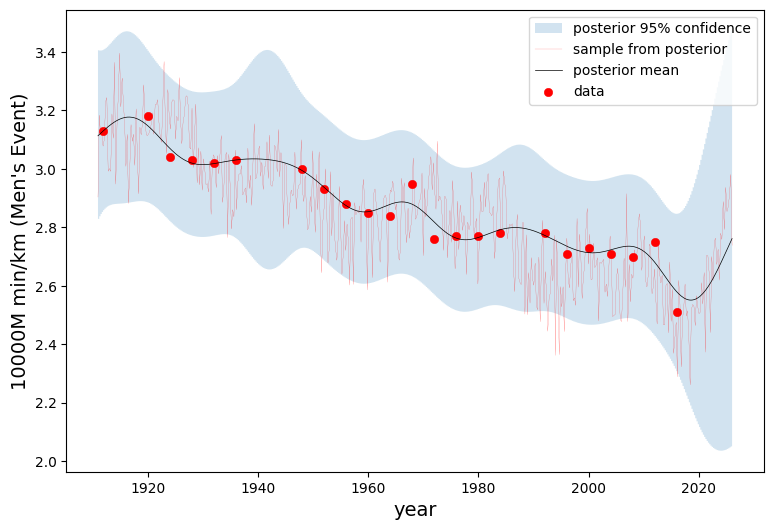

In [ ]:
event1 = dat[dat['Event'] == '10000M Men']
event1 = event1[event1['Medal']=='G']
event1 = event1.sort_values('Year')
event1_time = np.array(event1['Result'])
event1_mpk = []
for tm in event1_time:
    t = np.array(tm.split(':'), dtype=float)
    minutes_per_km = (t[0]*60 + t[1])/(60*10)
    event1_mpk.append(minutes_per_km)

event1['Minutes per Kilometer'] = np.round(event1_mpk,2)
event1 = event1.drop(columns=['Gender', 'Event'], axis=1)
event1.reset_index(drop=True, inplace=True)
event1_year = np.array(event1['Year'])
event1_result = np.array(event1['Minutes per Kilometer'])

event1_mu = lambda x: mu_fun(x, mu=3)
event1_rbf_K = lambda x, z: rbf_K_fun(x, z, h=7)

gp_olympic_event(event1_year, event1_result, event1_rbf_K, event1_mu, noise=0.01, event_name="10000M min/km (Men's Event)")

#### Event2: 10000M Women
- How you chose the kernel, mean, and noise.
    - kernel: I choose the Gaussian Kernel with $h=7$. Since the gap between every two Olympic Games is 4 and the h shouldn't be too small. This reflects the belief that performance trends evolve smoothly across each Olympic Game, rather than changing abruptly from one to the next.
    - mean: I set $m(x) = \mu$ (a constant mean), with $\mu = 3.5$ min/km as a rough baseline speed, which is observed from the experience. This prior anchors the model’s extrapolation outside the observed years.
    - noise: I set a small noise variance $\sigma^2 = 0.01$, which accounts for the inaccuracy of timing and small fluctuations in results between games.
- Why the plot does or doesn't look satisfactory to you
    - The plot looks statisfactory to me since it captures the steady improvement in the performance of Women's 10000M through the Olympic Games.
- If there are any events such as the 1904 marathon that are notable.
    - No. Every point is within the 95% confidence.
- What happens to the posterior mean (for example during WWII) if there are gaps in the data
    - No. Since the 10000M of Women was held only after 1992.

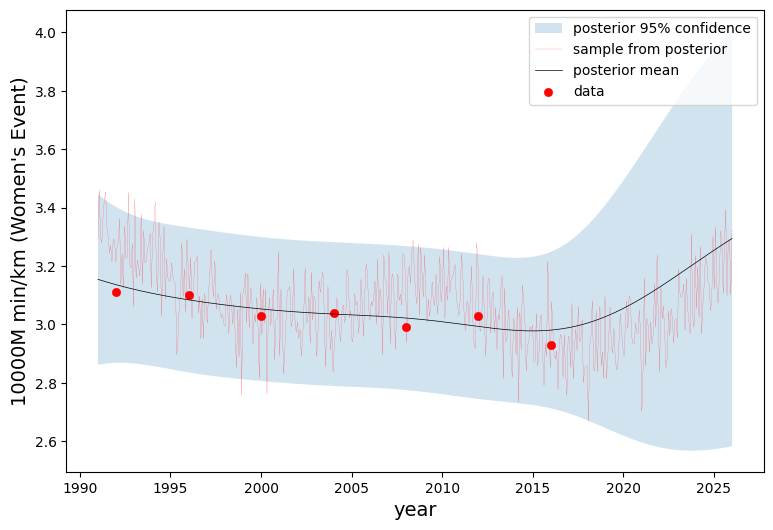

In [ ]:
event2 = dat[dat['Event'] == '10000M Women']
event2 = event2[event2['Medal']=='G']
event2 = event2.sort_values('Year')
event2_time = np.array(event2['Result'])
event2_mpk = []
for tm in event2_time:
    t = np.array(tm.split(':'), dtype=float)
    minutes_per_km = (t[0]*60 + t[1])/(60*10)
    event2_mpk.append(minutes_per_km)

event2['Minutes per Kilometer'] = np.round(event2_mpk,2)
event2 = event2.drop(columns=['Gender', 'Event'], axis=1)
event2.reset_index(drop=True, inplace=True)
event2_year = np.array(event2['Year'])
event2_result = np.array(event2['Minutes per Kilometer'])

event2_mu = lambda x: mu_fun(x, mu=3.5)
event2_rbf_K = lambda x, z: rbf_K_fun(x, z, h=7)

gp_olympic_event(event2_year, event2_result, event2_rbf_K, event2_mu, noise=0.01, event_name="10000M min/km (Women's Event)")

#### Event3: 5000M Men
- How you chose the kernel, mean, and noise.
    - kernel: I choose the Gaussian Kernel with $h=7$. Since the gap between every two Olympic Games is 4 and the h shouldn't be too small. This reflects the belief that performance trends evolve smoothly across each Olympic Game, rather than changing abruptly from one to the next.
    - mean: I set $m(x) = \mu$ (a constant mean), with $\mu = 2.7$ min/km as a rough baseline speed, which is observed from the experience. This prior anchors the model’s extrapolation outside the observed years.
    - noise: I set a small noise variance $\sigma^2 = 0.01$, which accounts for the inaccuracy of timing and small fluctuations in results between games.
- Why the plot does or doesn't look satisfactory to you
    - The plot looks statisfactory to me since it captures the tendency of steady improvement in the performance of Men's 5000M through the Olympic Games, though sometimes there were fluctuations. But it's understandable since weather, height, and many other reasons might influence the performance of an athlete.
- If there are any events such as the 1904 marathon that are notable.
    - No. Every point is within the 95% confidence.
- What happens to the posterior mean (for example during WWII) if there are gaps in the data
    - During the 1940s interval, the posterior mean smoothly interpolates between the 1936 and 1948 points, reflecting the GP’s prior assumption of temporal continuity rather than sudden jumps.

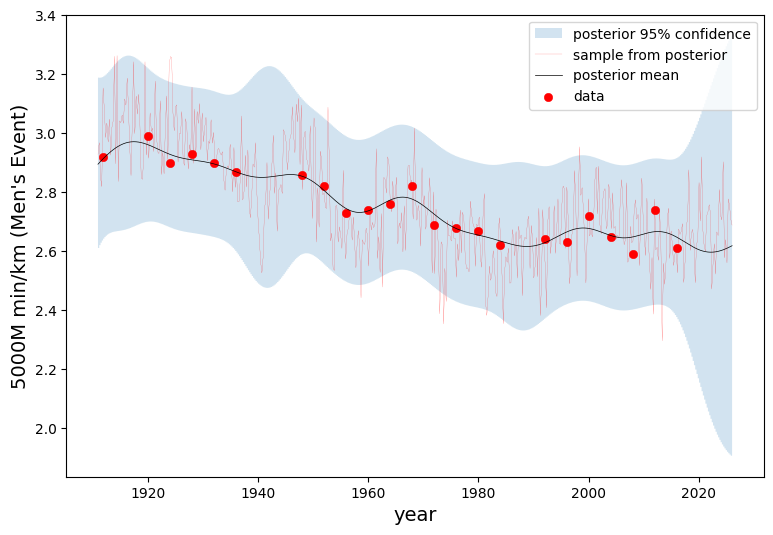

In [ ]:
event3 = dat[dat['Event'] == '5000M Men']
event3 = event3[event3['Medal']=='G']
event3 = event3.sort_values('Year')
event3_time = np.array(event3['Result'])
event3_mpk = []
for tm in event3_time:
    t = np.array(tm.split(':'), dtype=float)
    minutes_per_km = (t[0]*60 + t[1])/(60*5)
    event3_mpk.append(minutes_per_km)

event3['Minutes per Kilometer'] = np.round(event3_mpk,2)
event3 = event3.drop(columns=['Gender', 'Event'], axis=1)
event3.reset_index(drop=True, inplace=True)
event3_year = np.array(event3['Year'])
event3_result = np.array(event3['Minutes per Kilometer'])

event3_mu = lambda x: mu_fun(x, mu=2.7)
event3_rbf_K = lambda x, z: rbf_K_fun(x, z, h=7)

gp_olympic_event(event3_year, event3_result, event3_rbf_K, event3_mu, noise=0.01, event_name="5000M min/km (Men's Event)")

#### Event4: 5000M Women
- How you chose the kernel, mean, and noise.
    - kernel: I choose the Gaussian Kernel with $h=7$. Since the gap between every two Olympic Games is 4 and the h shouldn't be too small. This reflects the belief that performance trends evolve smoothly across each Olympic Game, rather than changing abruptly from one to the next.
    - mean: I set $m(x) = \mu$ (a constant mean), with $\mu = 3$ min/km as a rough baseline speed, which is observed from the experience. This prior anchors the model’s extrapolation outside the observed years.
    - noise: I set a small noise variance $\sigma^2 = 0.01$, which accounts for the inaccuracy of timing and small fluctuations in results between games.
- Why the plot does or doesn't look satisfactory to you
    - The plot looks statisfactory to me since it captures the tendency of steady improvement in the performance of Women's 5000M through the Olympic Games though sometimes there were fluctuations. But it's understandable since weather, height, and many other reasons might influence the performance of an athlete.
- If there are any events such as the 1904 marathon that are notable.
    - No. Every point is within the 95% confidence.
- What happens to the posterior mean (for example during WWII) if there are gaps in the data
    - No. Since the 5000M of Women was held only after 1996.

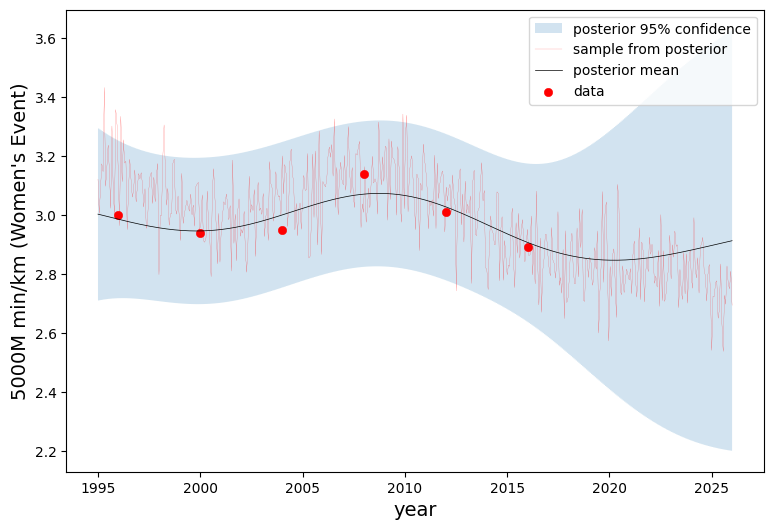

In [ ]:
event4 = dat[dat['Event'] == '5000M Women']
event4 = event4[event4['Medal']=='G']
event4 = event4.sort_values('Year')
event4_time = np.array(event4['Result'])
event4_mpk = []
for tm in event4_time:
    t = np.array(tm.split(':'), dtype=float)
    minutes_per_km = (t[0]*60 + t[1])/(60*5)
    event4_mpk.append(minutes_per_km)

event4['Minutes per Kilometer'] = np.round(event4_mpk,2)
event4 = event4.drop(columns=['Gender', 'Event'], axis=1)
event4.reset_index(drop=True, inplace=True)
event4_year = np.array(event4['Year'])
event4_result = np.array(event4['Minutes per Kilometer'])

event4_mu = lambda x: mu_fun(x, mu=3)
event4_rbf_K = lambda x, z: rbf_K_fun(x, z, h=7)

gp_olympic_event(event4_year, event4_result, event4_rbf_K, event4_mu, noise=0.01, event_name="5000M min/km (Women's Event)")

#### Event5: Long Jump Men
- How you chose the kernel, mean, and noise.
    - kernel: I choose the Gaussian Kernel with $h=7$. Since the gap between every two Olympic Games is 4 and the h shouldn't be too small. This reflects the belief that performance trends evolve smoothly across each Olympic Game, rather than changing abruptly from one to the next.
    - mean: I set $m(x) = \mu$ (a constant mean), with $\mu = 8$ m as a rough baseline distance, which is observed from the experience. This prior anchors the model’s extrapolation outside the observed years.
    - noise: I set a small noise variance $\sigma^2 = 0.01$, which accounts for the inaccuracy of timing and small fluctuations in results between games.
- Why the plot does or doesn't look satisfactory to you
    - The plot looks statisfactory to me since it captures the tendency of steady improvement in the performance of Men's Long Jump through the Olympic Games.
- If there are any events such as the 1904 marathon that are notable.
    - The first point of the year 1896 was almost outside of the 95% confidence. I think it might be because it was the first time long jump was held and people had no idea of how to get a good result.
- What happens to the posterior mean (for example during WWII) if there are gaps in the data
    - During the 1940s interval, the posterior mean smoothly interpolates between the 1936 and 1948 points, reflecting the GP’s prior assumption of temporal continuity rather than sudden jumps.
    - And it's the same for the 1970s and 1980s.

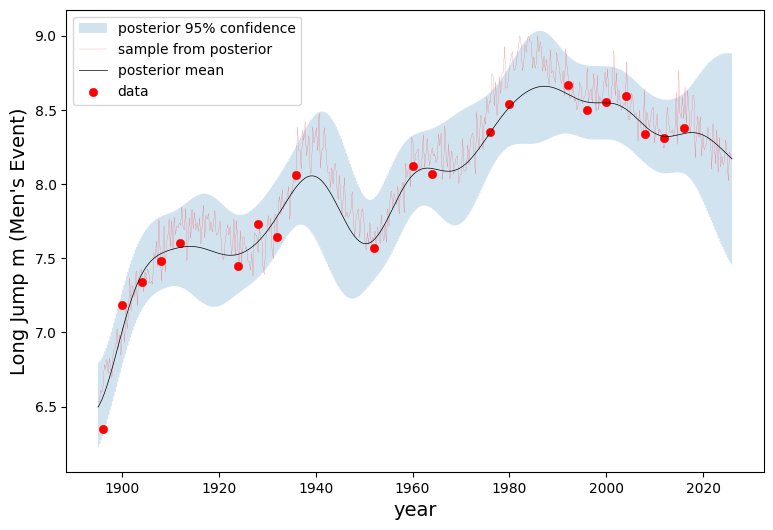

In [ ]:
event5 = dat[dat['Event'] == 'Long Jump Men']
event5 = event5[event5['Medal']=='G']
event5 = event5.sort_values('Year')
event5.reset_index(drop=True, inplace=True)
event5_year = np.array(event5['Year'])
event5_result = np.array(event5['Result']).astype(float)

event5_mu = lambda x: mu_fun(x, mu=8)
event5_rbf_K = lambda x, z: rbf_K_fun(x, z, h=7)

gp_olympic_event(event5_year, event5_result, event5_rbf_K, event5_mu, noise=0.01, event_name="Long Jump m (Men's Event)")

#### Event6: Long Jump Women
- How you chose the kernel, mean, and noise.
    - kernel: I choose the Gaussian Kernel with $h=7$. Since the gap between every two Olympic Games is 4 and the h shouldn't be too small. This reflects the belief that performance trends evolve smoothly across each Olympic Game, rather than changing abruptly from one to the next.
    - mean: I set $m(x) = \mu$ (a constant mean), with $\mu = 7$ m as a rough baseline distance, which is observed from the experience. This prior anchors the model’s extrapolation outside the observed years.
    - noise: I set a small noise variance $\sigma^2 = 0.01$, which accounts for the inaccuracy of timing and small fluctuations in results between games.
- Why the plot does or doesn't look satisfactory to you
    - The plot looks statisfactory to me since it captures the tendency of steady improvement in the performance of Women's Long Jump through the Olympic Games.
- If there are any events such as the 1904 marathon that are notable.
    - No. Every point is within the 95% confidence.
- What happens to the posterior mean (for example during WWII) if there are gaps in the data
    - During the 1970s and 1980s interval, the posterior mean smoothly interpolates between the points before and after the interval, reflecting the GP’s prior assumption of temporal continuity rather than sudden jumps.

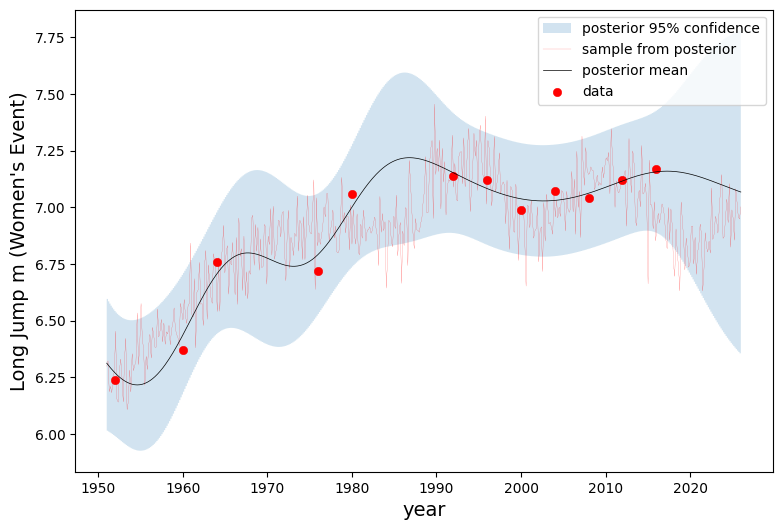

In [ ]:
event6 = dat[dat['Event'] == 'Long Jump Women']
event6 = event6[event6['Medal']=='G']
event6 = event6.sort_values('Year')
event6.reset_index(drop=True, inplace=True)
event6_year = np.array(event6['Year'])
event6_result = np.array(event6['Result']).astype(float)

event6_mu = lambda x: mu_fun(x, mu=7)
event6_rbf_K = lambda x, z: rbf_K_fun(x, z, h=7)

gp_olympic_event(event6_year, event6_result, event6_rbf_K, event6_mu, noise=0.01, event_name="Long Jump m (Women's Event)")

## Problem 3: Double descent! (20 points)

<a href="https://skitheworld.com/2018/12/wurtele-twins-appointed-order-canada/"><img src="https://raw.githubusercontent.com/YData123/sds365-fa25/main/assignments/assn2/double.jpg" width="200" align="left" style="margin:20px 30px 20px 5px"></a>


In this problem you will explore the "double descent" phenomenon that was recently
discovered as a key principle underlying the performance of deep neural networks.
The problem setup is a "random features" version of a 2-layer neural network. The weights in the first layer are random and fixed, and the weights in the second layer are estimated from data. As we increase the number of neurons in the hidden layer, the dimension $p$ of model increases. It's helpful to define the ratio $\gamma = p/n$ of variables to sample points. If $\gamma < 1$ then we want to use the OLS estimator, and if $\gamma > 1$ we want to use the minimum norm estimator.
<br>

Your mission (should you choose to accept it), is

1. Implement a function `OLS_or_minimum_norm` that computes the least squares solution when $\gamma < 1$, and the minimum norm solution when $\gamma > 1$. (When $\gamma=1$ the estimator does not, in general, exist.)
1. Run the main code we give you to average over many trials, and to compute and plot the estimated risk for a range of values of $\gamma$.
1. Next, extend the starter code so that you compute (estimates of) the squared-bias and variance of the models. To do this, note that you'll need access to the true regression function, which is provided. You may want to refer to the demo code for smoothing kernels as an example.
1. Using your new code, extend the plotting function we provide so that you plot
the squared-bias, variance, and risk together on the same plot.
1. Finally, comment on the results, describing why it might make sense that the squared bias, variance, and risk have the given shapes that they do.
1. Show that in the overparameterized regime $\gamma > 1$, as $\lambda \to 0$, the ridge regression estimator converges to the minimum norm estimator.


By doing this exercise you will solidify your understanding of the meaning of bias and variance, and also gain a better understanding of the "double descent" phenomenon for overparameterized neural networks,
and their striking resistance to overfitting.

We're available in OH to help with any issues you run into!

If you have any interest in background reading on this topic (not expected or required), we recommend Hastie et al., ["Surprises in high-dimensional ridgeless least squares regression"](https://www.stat.cmu.edu/~ryantibs/papers/ridgeless.pdf).



In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

### Problem 3.1

Implement the function `OLS_or_minimum_norm` that computes the OLS solution for $\gamma < 1$, and the minimum norm solution for $\gamma > 1$.

In [ ]:
def OLS_or_minimum_norm(X, y):
    n, p = X.shape
    if p < n:
        beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
    elif p > n:
        beta_hat = X.T @ np.linalg.inv(X @ X.T) @ y
    else:
        raise ValueError("p == n")
    return beta_hat

In [ ]:
# A plotting function we provide. No need to change this, although you can if you'd like.

def plot_double_descent_risk(gammas, risk, sigma):
    gammas = np.round(gammas, 2)
    fig, ax = plt.subplots(figsize=(10,6))
    tick_pos = np.zeros(len(gammas))
    for i in np.arange(len(gammas)):
        if gammas[i] <= 1:
            tick_pos[i] = gammas[i] * 10
        else:
            tick_pos[i] = gammas[i] + 9
    ax.axvline(x=tick_pos[np.array(gammas)==1][0], linestyle='dashed', color='gray')
    ax.axhline(y=sigma**2, linestyle='dashed', color='gray')
    ax.scatter(tick_pos, risk, color='salmon')
    ax.plot(tick_pos, risk, color='gray', linewidth=.5)

    tickgam = [gam for gam in gammas if (gam > .05 and gam <= .9) or gam >= 2 or gam == 1]
    ticks = [tick_pos[j] for j in np.arange(len(tick_pos)) if gammas[j] in tickgam]
    ax.xaxis.set_ticks(ticks)
    ax.xaxis.set_ticklabels(tickgam)

    plt.xlabel(r'$\gamma = \frac{p}{n}$', fontsize=18)
    _ = plt.ylabel('Risk', fontsize=18)

### Data setup

The following cell sets up our data. The inputs $X$ are
random Gaussian vectors of dimension $d=10$. Then, we map these
using a neural network with fixed, Gaussian weights, to get random features
corresponding to $p^* = 150$ hidden neurons. The second layer
coefficients are $\beta^* \in {\mathbb R}^{p^*}$, which are fixed.
This defines the true model.


In [ ]:
# just execute this cell, after you define the function above.

np.random.seed(123456)

sigma = 1
d = 10
p_star = 150
signal_size = 5

W_star = (1/np.sqrt(d)) * np.random.randn(d, p_star)
beta_star = np.arange(p_star)
beta_star = signal_size * beta_star / np.sqrt(np.sum(beta_star**2))

N = 10000
X = np.random.randn(N, d)

# f_star is the true regression function, for computing the squared bias
f_star = np.dot(np.tanh(np.dot(X, W_star)), beta_star)
noise = sigma * np.random.randn(N)
y = f_star + noise
yf = np.concatenate((y.reshape(N,1), f_star.reshape(N,1)), axis=1)

### Train a sequence of models for different values of $\gamma$

Next, we train a sequence of models for different values of $\gamma$, always
fixing the sample size at $n=200$, but varying the dimension $p = \gamma n$.
When $p < p^*$ we just take the first $p$ features in the true model.
When $p > p^*$ we add $p-p^*$ neurons to the hidden layer, with their
own random weights.

In the code below, we loop over the different values of $\gamma$,
and for each $\gamma$ we run $100$ trials, each time generating
a new training set of size $n=200$. The model (either OLS or minimum norm) is then computed, the MSE is computed, and finally the risk is estimated by averaging over all $100$ trials.


In [ ]:
trials = 100
n = 200

gammas = list(np.arange(.1, 1, .1)) + [.92, .94, 1, 1.1, 1.2, 1.4, 1.6] + list(np.arange(2, 11, 1))
gammas = [.01, .05] + gammas
risk = []
for gamma in gammas:
    err = []
    p = int(n * gamma)
    if gamma == 1:
        risk.append(np.inf)
        continue
    W = (1/np.sqrt(d)) * np.random.randn(d, p)
    W[:,:min(p, p_star)] = W_star[:,:min(p, p_star)]
    for i in np.arange(trials):
        X_train, X_test, yf_train, yf_test = train_test_split(X, yf, train_size=n, test_size=1000)
        H_train = np.tanh(np.dot(X_train, W))
        H_test = np.tanh(np.dot(X_test, W))
        beta_hat = OLS_or_minimum_norm(H_train, yf_train[:,0])
        yhat_test = H_test @ beta_hat
        err.append(np.mean((yhat_test - yf_test[:,0])**2))
    print('gamma=%.2f  p=%d  n=%d  risk=%.3f' % (gamma, p, n, np.mean(err)))
    risk.append(np.mean(err))


gamma=0.01  p=2  n=200  risk=7.373
gamma=0.05  p=10  n=200  risk=4.146
gamma=0.10  p=20  n=200  risk=2.294
gamma=0.20  p=40  n=200  risk=2.099
gamma=0.30  p=60  n=200  risk=2.267
gamma=0.40  p=80  n=200  risk=2.534
gamma=0.50  p=100  n=200  risk=3.011
gamma=0.60  p=120  n=200  risk=3.573
gamma=0.70  p=140  n=200  risk=4.443
gamma=0.80  p=160  n=200  risk=6.885
gamma=0.90  p=180  n=200  risk=15.773
gamma=0.92  p=184  n=200  risk=20.500
gamma=0.94  p=188  n=200  risk=31.661
gamma=1.10  p=220  n=200  risk=24.179
gamma=1.20  p=240  n=200  risk=14.097
gamma=1.40  p=280  n=200  risk=8.089
gamma=1.60  p=320  n=200  risk=6.543
gamma=2.00  p=400  n=200  risk=5.301
gamma=3.00  p=600  n=200  risk=4.073
gamma=4.00  p=800  n=200  risk=3.658
gamma=5.00  p=1000  n=200  risk=3.430
gamma=6.00  p=1200  n=200  risk=3.309
gamma=7.00  p=1400  n=200  risk=3.135
gamma=8.00  p=1600  n=200  risk=3.190
gamma=9.00  p=1800  n=200  risk=3.056
gamma=10.00  p=2000  n=200  risk=3.062


### Plot the risk

At this point, you can plot the risk by just evaluating the cell below.
This should reveal the "double descent" behavior.


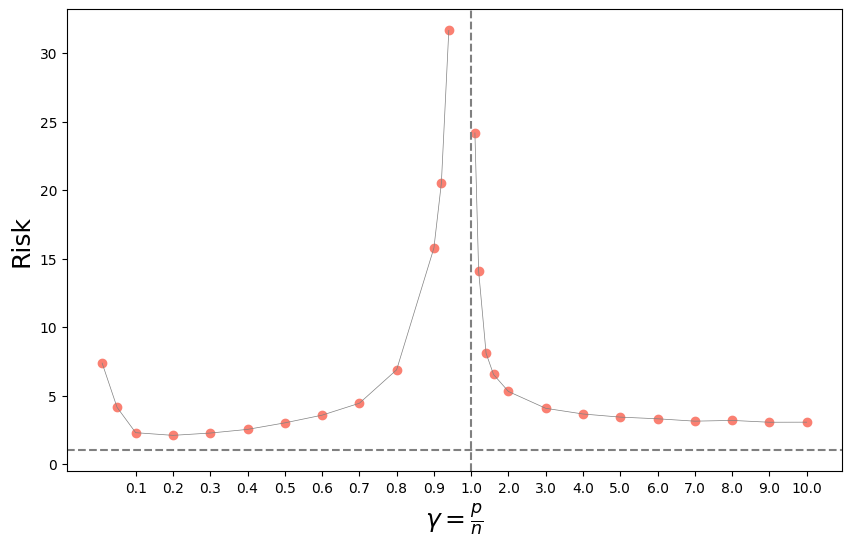

In [ ]:
# Just evaluate the next line
plot_double_descent_risk(gammas, risk, sigma)

### Problem 3.2

Comment on the results. Explain why the risk plot does or does not make sense
in each regime: The underparameterized regime $\gamma < 1$, and the overparameterized
regime $\gamma > 1$. Is the curve "U-shaped" in the underparameterized regime? Why or why not?
What about in the overparameterized regime? You will be able to give better answers to these questions when you estimate the bias and variance below.


- The underparameterized regime $\gamma < 1$
  - the risk plot tends to have the classical U-shape curve
  - When the model dimension is small compared with the number of samples
    - the model is too simple to capture the true regression function, leading to large squared bias but very low variance
    - when the model dimension grows larger, the bias decreases because the model becomes more accurate, but the variance increases due to its sensitivity to noise
  - The combination of these decreasing bias and increasing variance makes the risk plot a U-shaped curve
- The overparameterized regime $\gamma > 1$
  - the risk plot does not have the classical U-shape curve
  - as the model dimension grows larger, the model could fit the data better, so the squared bias of the minimum norm solution remains low.
  - while the variance is relatively stable
  - so the overall risk curve continues to decrease

### Problem 3.3

Now, modify the above code so that you can estimate both the squared bias and the
variance of the estimator. Before you do this, you may want to revisit the kernel smoothing demo from class, where we computed the squared bias, variance, and risk. You'll need the true function, which is provided in the variable `yf`.  You should not have to write a lot of code, but can compute the bias and variance after you store the predicted values on the test data for each trial.

Plot the results, by plotting both the squared bias, the variance, and the risk for the sequence of gammas. To do this you will have to modify the plotting function appropriately, but this again involves minimal changes. When you obtain your final plot, comment
on the shape of the bias and variance curves, as above for Problem 3.2.


In [ ]:
trials = 100
n = 200

gammas = list(np.arange(.1, 1, .1)) + [.92, .94, 1, 1.1, 1.2, 1.4, 1.6] + list(np.arange(2, 11, 1))
gammas = [.01, .05] + gammas
risk = []
squared_bias = []
variance = []
for gamma in gammas:
    err = []
    estimate = []
    p = int(n * gamma)
    if gamma == 1:
        risk.append(np.inf)
        squared_bias.append(np.inf)
        variance.append(np.inf)
        continue
    W = (1/np.sqrt(d)) * np.random.randn(d, p)
    W[:,:min(p, p_star)] = W_star[:,:min(p, p_star)]
    X_remain, X_test, yf_remain, yf_test = train_test_split(X, yf, test_size=1000)
    for i in np.arange(trials):
        X_train, _, yf_train, _ = train_test_split(X_remain, yf_remain, train_size=n, test_size=1000)
        H_train = np.tanh(np.dot(X_train, W))
        H_test = np.tanh(np.dot(X_test, W))
        beta_hat = OLS_or_minimum_norm(H_train, yf_train[:,0])
        yhat_test = H_test @ beta_hat
        estimate.append(yhat_test)
        err.append(np.mean((yhat_test - yf_test[:,0])**2))

    estimate = np.array(estimate)

    # risk_ = np.mean(err)
    squared_bias_ = np.mean((np.mean(estimate, axis=0) - yf_test[:, 1])**2)
    variance_ = np.mean(np.var(estimate, axis=0))
    risk_ = squared_bias_ + variance_

    # risk.append(risk_)
    squared_bias.append(squared_bias_)
    variance.append(variance_)
    risk.append(risk_)

    print('gamma=%.2f  p=%d  n=%d  risk=%.3f  bias=%.3f  variance=%.3f' % (gamma, p, n, risk_, squared_bias_, variance_))


gamma=0.01  p=2  n=200  risk=6.665  bias=6.596  variance=0.069
gamma=0.05  p=10  n=200  risk=3.175  bias=2.974  variance=0.200
gamma=0.10  p=20  n=200  risk=1.236  bias=0.979  variance=0.257
gamma=0.20  p=40  n=200  risk=1.171  bias=0.720  variance=0.451
gamma=0.30  p=60  n=200  risk=1.286  bias=0.539  variance=0.747
gamma=0.40  p=80  n=200  risk=1.511  bias=0.443  variance=1.068
gamma=0.50  p=100  n=200  risk=2.083  bias=0.395  variance=1.688
gamma=0.60  p=120  n=200  risk=2.745  bias=0.283  variance=2.462
gamma=0.70  p=140  n=200  risk=3.740  bias=0.142  variance=3.598
gamma=0.80  p=160  n=200  risk=6.022  bias=0.078  variance=5.943
gamma=0.90  p=180  n=200  risk=13.990  bias=0.182  variance=13.807
gamma=0.92  p=184  n=200  risk=21.442  bias=0.237  variance=21.205
gamma=0.94  p=188  n=200  risk=27.716  bias=0.365  variance=27.351
gamma=1.10  p=220  n=200  risk=22.226  bias=0.216  variance=22.010
gamma=1.20  p=240  n=200  risk=13.037  bias=0.168  variance=12.870
gamma=1.40  p=280  n=2

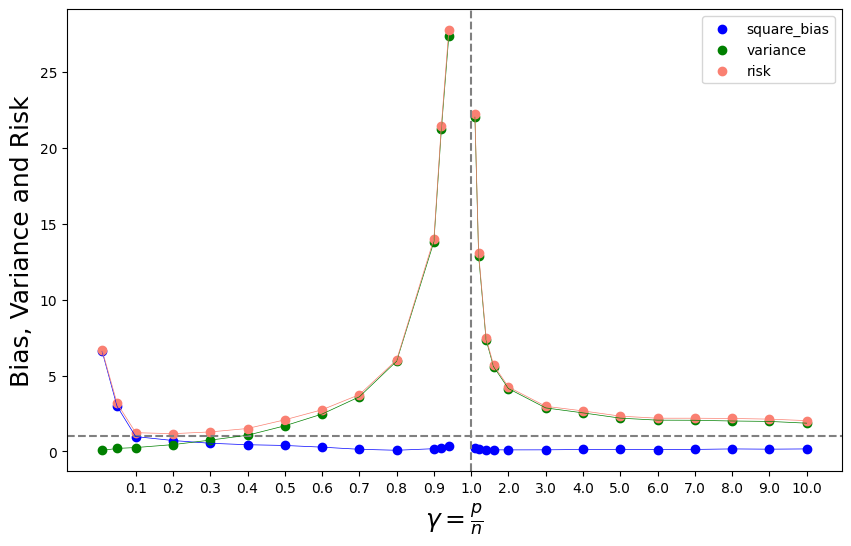

In [ ]:
def plot_double_descent_risk2(gammas, squared_bias, variance, risk, sigma):
    gammas = np.round(gammas, 2)
    fig, ax = plt.subplots(figsize=(10,6))
    tick_pos = np.zeros(len(gammas))
    for i in np.arange(len(gammas)):
        if gammas[i] <= 1:
            tick_pos[i] = gammas[i] * 10
        else:
            tick_pos[i] = gammas[i] + 9
    ax.axvline(x=tick_pos[np.array(gammas)==1][0], linestyle='dashed', color='gray')
    ax.axhline(y=sigma**2, linestyle='dashed', color='gray')
    ax.scatter(tick_pos, squared_bias, color='blue', label='square_bias')
    ax.plot(tick_pos, squared_bias, color='blue', linewidth=.5)
    ax.scatter(tick_pos, variance, color='green', label='variance')
    ax.plot(tick_pos, variance, color='green', linewidth=.5)
    ax.scatter(tick_pos, risk, color='salmon', label='risk')
    ax.plot(tick_pos, risk, color='salmon', linewidth=.5)


    tickgam = [gam for gam in gammas if (gam > .05 and gam <= .9) or gam >= 2 or gam == 1]
    ticks = [tick_pos[j] for j in np.arange(len(tick_pos)) if gammas[j] in tickgam]
    ax.xaxis.set_ticks(ticks)
    ax.xaxis.set_ticklabels(tickgam)

    plt.xlabel(r'$\gamma = \frac{p}{n}$', fontsize=18)
    plt.ylabel('Bias, Variance and Risk', fontsize=18)
    plt.legend(loc='upper right')

plot_double_descent_risk2(gammas, squared_bias, variance, risk, sigma)

### Problem 3.4

In class, we discussed the interpretation of the minimum-norm estimator $ \hat{\beta}_{\text{mn}} $. Geometrically, we can describe $ \hat{\beta}_{\text{mn}} $ as the orthogonal projection of the zero vector in $ \mathbb{R}^p $ onto the $ (p-1) $-dimensional hyperplane $ \{ \beta : X\beta = Y \} $.  

This can also be viewed as "ridgeless" regression. In ridge regression, we minimize the objective function
$$
\| Y - X\beta  \|_2^2 + \lambda \| \beta \|_2^2,
$$
which has the closed-form solution
$$
\hat{\beta}_{\lambda} = (X^T X + \lambda I)^{-1} X^T Y.
$$

In the overparameterized regime where $ p > n $, it can be shown that as $ \lambda \to 0 $, $ \hat{\beta}_{\lambda} $ converges to $ \hat{\beta}_{\text{mn}} $.

Your task is to show that as $ \lambda \to 0 $, the limit of the ridge regression estimator $ \hat{\beta}_{\lambda} $, in the overparameterized regime where $ \gamma > 1 $, is the minimum-norm estimator $ \hat{\beta}_{\text{mn}} $. You may want to use the Woodbury formula for this derivation.


_Hint_:
1. Applying the simplified version of Woodbury formula
$$
(I + UV^T)^{-1} = I - U(I + V^T U)^{-1} V^T.
$$
we can derive the identity:
$$
(X^T X + \lambda I_p)^{-1} X^T = X^T (X X^T + \lambda I_n)^{-1},
$$
2. You might consider using the Woodbury formula twice.



![](./S&DS6650-hw2.jpg)